In [1]:
import pandas as pd

df = pd.read_csv(
    "../data/superstore.csv",
    sep="\t"
)

df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    dayfirst=False,
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    dayfirst=False,
    format="mixed"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,2016-11-08,2016-11-11,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,2016-06-12,2016-06-16,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,2015-10-11,2015-10-18,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [2]:
df["Month_Year"] = df["Order Date"].dt.to_period("M")

In [3]:
monthly_sales = (
    df.groupby("Month_Year")["Sales"]
    .sum()
)

monthly_sales.head()

Month_Year
2014-01    14236.895
2014-02     4519.892
2014-03    55691.009
2014-04    28295.345
2014-05    23648.287
Freq: M, Name: Sales, dtype: float64

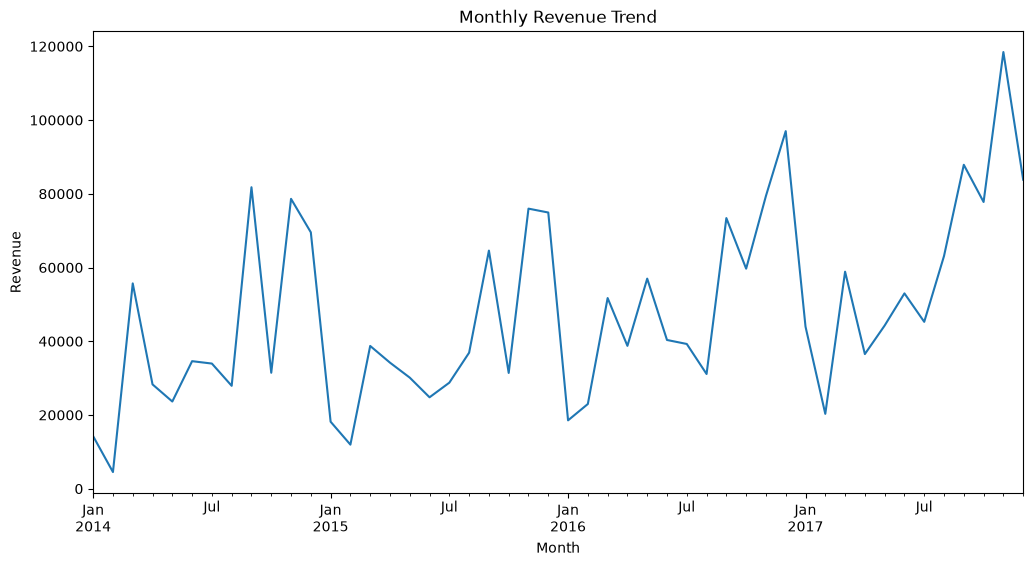

In [4]:
import matplotlib.pyplot as plt

monthly_sales.plot(
    figsize=(12,6)
)

plt.title("Monthly Revenue Trend")
plt.xlabel("Month")
plt.ylabel("Revenue")

plt.show()

In [5]:
top_products = (
    df.groupby("Product Name")["Sales"]
    .sum()
    .sort_values(ascending=False)
    .head(10)
)

top_products

Product Name
Canon imageCLASS 2200 Advanced Copier                                          61599.824
Fellowes PB500 Electric Punch Plastic Comb Binding Machine with Manual Bind    27453.384
Cisco TelePresence System EX90 Videoconferencing Unit                          22638.480
HON 5400 Series Task Chairs for Big and Tall                                   21870.576
GBC DocuBind TL300 Electric Binding System                                     19823.479
GBC Ibimaster 500 Manual ProClick Binding System                               19024.500
Hewlett Packard LaserJet 3310 Copier                                           18839.686
HP Designjet T520 Inkjet Large Format Printer - 24" Color                      18374.895
GBC DocuBind P400 Electric Binding System                                      17965.068
High Speed Automatic Electric Letter Opener                                    17030.312
Name: Sales, dtype: float64

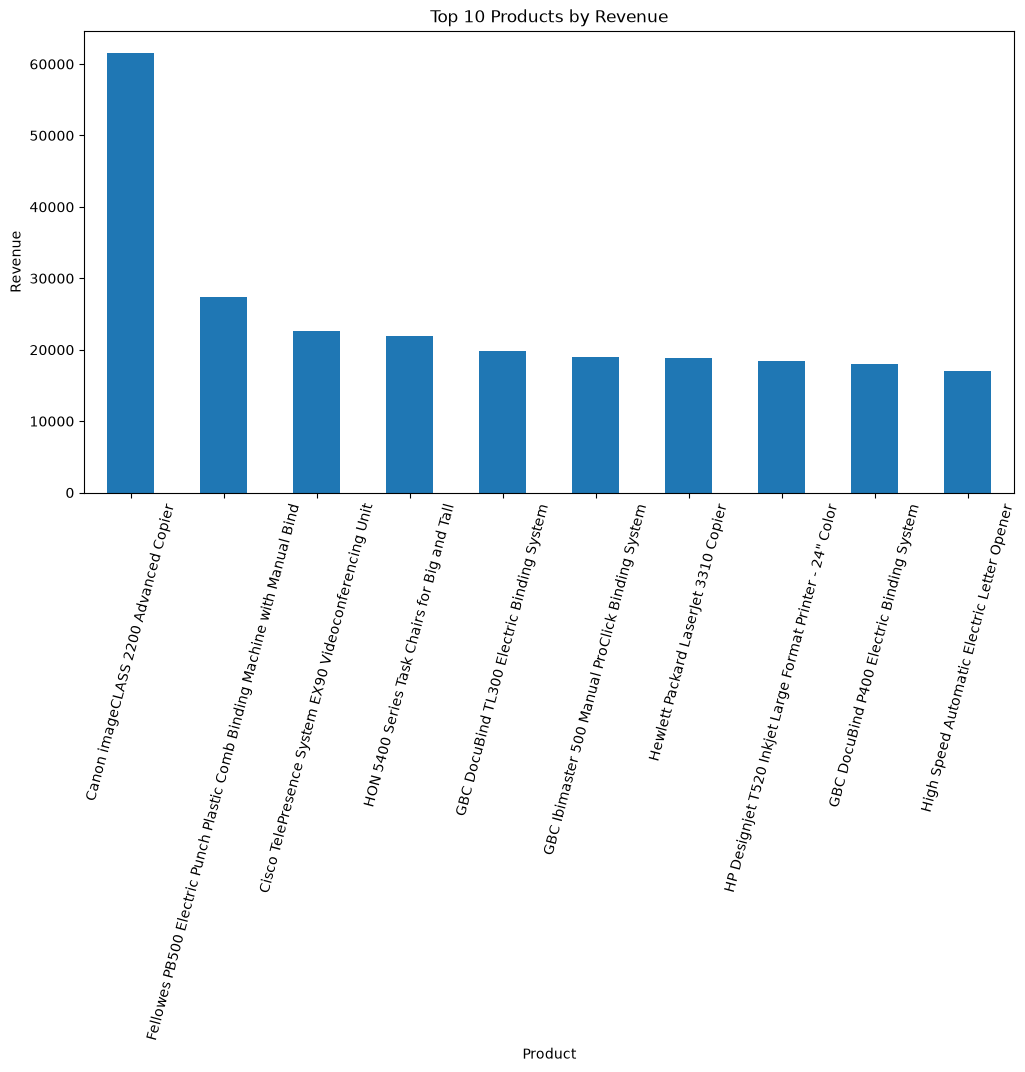

In [6]:
import matplotlib.pyplot as plt

top_products.plot(
    kind="bar",
    figsize=(12,6)
)

plt.title("Top 10 Products by Revenue")
plt.xlabel("Product")
plt.ylabel("Revenue")

plt.xticks(rotation=75)

plt.show()

In [7]:
category_sales = (
    df.groupby("Category")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

category_sales

Category
Technology         836154.0330
Furniture          741999.7953
Office Supplies    719047.0320
Name: Sales, dtype: float64

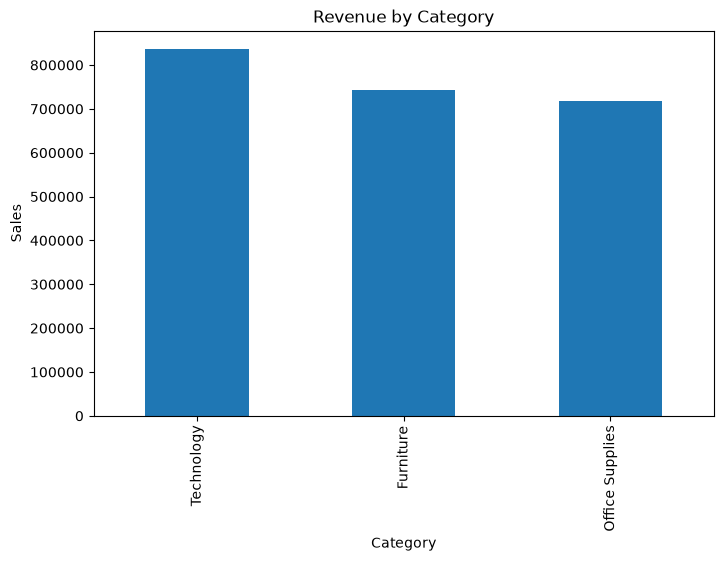

In [8]:
import matplotlib.pyplot as plt

category_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Category")
plt.xlabel("Category")
plt.ylabel("Sales")

plt.show()

In [9]:
region_sales = (
    df.groupby("Region")["Sales"]
    .sum()
    .sort_values(ascending=False)
)

region_sales

Region
West       725457.8245
East       678781.2400
Central    501239.8908
South      391721.9050
Name: Sales, dtype: float64

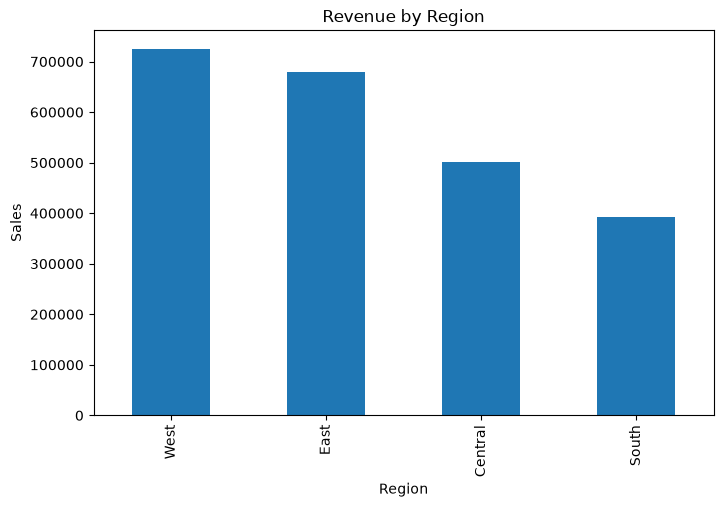

In [10]:
import matplotlib.pyplot as plt

region_sales.plot(
    kind="bar",
    figsize=(8,5)
)

plt.title("Revenue by Region")
plt.xlabel("Region")
plt.ylabel("Sales")

plt.show()

In [11]:
total_sales = df["Sales"].sum()

total_orders = df["Order ID"].nunique()

total_products = df["Product Name"].nunique()

total_profit = df["Profit"].sum()

print("Total Sales:", round(total_sales,2))
print("Total Orders:", total_orders)
print("Unique Products:", total_products)
print("Total Profit:", round(total_profit,2))

Total Sales: 2297200.86
Total Orders: 5009
Unique Products: 1850
Total Profit: 286397.02


In [12]:
print("Top Category:", category_sales.idxmax())
print("Top Region:", region_sales.idxmax())
print("Top Product:", top_products.idxmax())

Top Category: Technology
Top Region: West
Top Product: Canon imageCLASS 2200 Advanced Copier


# Business Insights

1. Revenue fluctuates across months instead of growing steadily.

2. A small number of products contribute significantly to total sales.

3. Technology is the highest revenue-generating category.

4. West region performs better than other regions.

5. The business generated strong overall profitability.


# Recommendations

1. Increase marketing and inventory focus on top-performing products.

2. Expand successful strategies from West region into lower-performing regions.

3. Invest more in Technology category offerings.

4. Monitor revenue fluctuations and identify seasonal patterns.

5. Track KPIs regularly to support business decisions.

In [13]:
df["Month_Year"] = df["Order Date"].dt.to_period("M")

In [14]:
# Create Month-Year column

df["Month_Year"] = df["Order Date"].dt.to_period("M")

df[["Order Date", "Month_Year"]].head()

,Order Date,Month_Year
0,2016-11-08,2016-11
1,2016-11-08,2016-11
2,2016-06-12,2016-06
3,2015-10-11,2015-10
4,2015-10-11,2015-10


In [15]:
df["Order Date"] = pd.to_datetime(
    df["Order Date"],
    format="mixed"
)

df["Ship Date"] = pd.to_datetime(
    df["Ship Date"],
    format="mixed"
)

In [16]:
# Duplicate rows

df.duplicated().sum()

np.int64(0)

In [17]:
# Missing values

df.isnull().sum()

Row ID           0
Order ID         0
Order Date       0
Ship Date        0
Ship Mode        0
Customer ID      0
Customer Name    0
Segment          0
Country          0
City             0
State            0
Postal Code      0
Region           0
Product ID       0
Category         0
Sub-Category     0
Product Name     0
Sales            0
Quantity         0
Discount         0
Profit           0
Month_Year       0
dtype: int64

In [18]:
df.isnull().sum()
df.shape

(9994, 22)

In [19]:
print("Rows and Columns:", df.shape)

df.info()

Rows and Columns: (9994, 22)
<class 'pandas.DataFrame'>
RangeIndex: 9994 entries, 0 to 9993
Data columns (total 22 columns):
 #   Column         Non-Null Count  Dtype         
---  ------         --------------  -----         
 0   Row ID         9994 non-null   int64         
 1   Order ID       9994 non-null   str           
 2   Order Date     9994 non-null   datetime64[us]
 3   Ship Date      9994 non-null   datetime64[us]
 4   Ship Mode      9994 non-null   str           
 5   Customer ID    9994 non-null   str           
 6   Customer Name  9994 non-null   str           
 7   Segment        9994 non-null   str           
 8   Country        9994 non-null   str           
 9   City           9994 non-null   str           
 10  State          9994 non-null   str           
 11  Postal Code    9994 non-null   int64         
 12  Region         9994 non-null   str           
 13  Product ID     9994 non-null   str           
 14  Category       9994 non-null   str           
 15  Sub

In [20]:
import pandas as pd

df = pd.read_csv(
    "../data/superstore.csv",
    sep="\t"
)

df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164


In [21]:
print("Notebook Working")

Notebook Working


In [22]:
import pandas as pd

df = pd.read_csv(
    "../data/superstore.csv",
    sep="\t"
)

print(df.shape)

(9994, 21)


In [23]:
df.head()

,Row ID,Order ID,Order Date,Ship Date,Ship Mode,Customer ID,Customer Name,Segment,Country,City,...,Postal Code,Region,Product ID,Category,Sub-Category,Product Name,Sales,Quantity,Discount,Profit
0,1,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-BO-10001798,Furniture,Bookcases,Bush Somerset Collection Bookcase,261.9600,2,0.00,41.9136
1,2,CA-2016-152156,11-08-2016,11-11-2016,Second Class,CG-12520,Claire Gute,Consumer,United States,Henderson,...,42420,South,FUR-CH-10000454,Furniture,Chairs,"Hon Deluxe Fabric Upholstered Stacking Chairs,...",731.9400,3,0.00,219.5820
2,3,CA-2016-138688,06-12-2016,6/16/2016,Second Class,DV-13045,Darrin Van Huff,Corporate,United States,Los Angeles,...,90036,West,OFF-LA-10000240,Office Supplies,Labels,Self-Adhesive Address Labels for Typewriters b...,14.6200,2,0.00,6.8714
3,4,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,FUR-TA-10000577,Furniture,Tables,Bretford CR4500 Series Slim Rectangular Table,957.5775,5,0.45,-383.0310
4,5,US-2015-108966,10-11-2015,10/18/2015,Standard Class,SO-20335,Sean O'Donnell,Consumer,United States,Fort Lauderdale,...,33311,South,OFF-ST-10000760,Office Supplies,Storage,Eldon Fold 'N Roll Cart System,22.3680,2,0.20,2.5164
